## Optimizing Digital Payment Performance using Quasi A/B Testing

Business Problem:
A fintech company wants to evaluate whether modern digital payment channels perform better than traditional payment channels in terms of fraud rate, transaction value, and transaction risk.

Since the dataset does not originate from a randomized experiment, a quasi-experimental A/B testing framework is used to compare two payment channel groups.

Objectives
Understand customer transaction behavior
Compare traditional and digital payment channels
Measure fraud and transaction risk
Perform statistical hypothesis testing
Provide data-driven business recommendations

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
#Load Dataset
df=pd.read_csv("C:/Users/Sandleen Sethi/Downloads/archive/nibss_fraud_dataset.csv")
dictionary_df=pd.read_csv("C:/Users/Sandleen Sethi/Downloads/archive/data_dictionary.csv")
df.head()

,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,TXN_F08A86FFD87C,CUST_0002AED1,2023-01-14 04:31:09,32266.83,Mobile,Grocery,Sterling,Other,30-39,4,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,TXN_C2D08134EC83,CUST_0002AED1,2023-01-17 11:20:13,72530.49,Web,Entertainment,UBA,Other,30-39,11,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,TXN_B9499111901D,CUST_0002AED1,2023-01-22 02:17:46,168152.87,Mobile,Transport,Wema,Other,30-39,2,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,TXN_48DB1D526A3B,CUST_0002AED1,2023-01-24 08:18:23,16439.93,Mobile,Entertainment,FCMB,Other,30-39,8,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,TXN_56DB1E28B758,CUST_0002AED1,2023-02-01 15:39:53,9922.68,POS,Education,FirstBank,Other,30-39,15,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251


## Dataset Overview

This section explores the structure and quality of the dataset before any preprocessing or analysis.

The objective is to understand the size of the dataset, data types, missing values, duplicate records, and column descriptions. Performing these checks helps identify potential data quality issues and ensures that the dataset is suitable for further analysis.

In [3]:
#Dataset Shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 1000000
Columns: 38


The dataset contains **1,000,000 rows** and **38 columns**, providing a comprehensive view of digital payment transactions across multiple payment channels.

In [4]:
df.head()

,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,TXN_F08A86FFD87C,CUST_0002AED1,2023-01-14 04:31:09,32266.83,Mobile,Grocery,Sterling,Other,30-39,4,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,TXN_C2D08134EC83,CUST_0002AED1,2023-01-17 11:20:13,72530.49,Web,Entertainment,UBA,Other,30-39,11,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,TXN_B9499111901D,CUST_0002AED1,2023-01-22 02:17:46,168152.87,Mobile,Transport,Wema,Other,30-39,2,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,TXN_48DB1D526A3B,CUST_0002AED1,2023-01-24 08:18:23,16439.93,Mobile,Entertainment,FCMB,Other,30-39,8,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,TXN_56DB1E28B758,CUST_0002AED1,2023-02-01 15:39:53,9922.68,POS,Education,FirstBank,Other,30-39,15,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251


### Initial Data Preview

The first five records provide an overview of the dataset structure. Each row represents a single transaction and contains customer information, transaction details, behavioral features, fraud indicators, and engineered risk scores.

In [5]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1000000 non-null  object 
 1   customer_id           1000000 non-null  object 
 2   timestamp             1000000 non-null  object 
 3   amount                1000000 non-null  float64
 4   channel               1000000 non-null  object 
 5   merchant_category     1000000 non-null  object 
 6   bank                  1000000 non-null  object 
 7   location              1000000 non-null  object 
 8   age_group             1000000 non-null  object 
 9   hour                  1000000 non-null  int64  
 10  day_of_week           1000000 non-null  int64  
 11  month                 1000000 non-null  int64  
 12  is_weekend            1000000 non-null  bool   
 13  is_peak_hour          1000000 non-null  bool   
 14  tx_count_24h          1000000 non-n

### Dataset Information

The dataset contains **1,000,000 transaction records** with **38 features**.

The features include:

- Customer identifiers
- Transaction details
- Payment channels
- Temporal information
- Customer behavioral metrics
- Fraud labels
- Risk scoring variables

Most variables already have appropriate data types. However, the `timestamp` column is currently stored as an object and will be converted to a datetime format during data cleaning.

In [6]:
#Missing Values
df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
amount                       0
channel                      0
merchant_category            0
bank                         0
location                     0
age_group                    0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
is_peak_hour                 0
tx_count_24h                 0
amount_sum_24h               0
amount_mean_7d               0
amount_std_7d                0
tx_count_total               0
amount_mean_total            0
amount_std_total             0
channel_diversity            0
location_diversity           0
amount_vs_mean_ratio         0
online_channel_ratio         0
is_fraud                     0
fraud_technique         997000
hour_sin                     0
hour_cos                     0
day_sin                      0
day_cos                      0
month_sin                    0
month_co

### Missing Value Analysis

The dataset is highly complete, with no missing values in the analytical features.

The only column containing missing values is `fraud_technique`, where approximately 997,000 records are null. This is expected because the fraud technique is only recorded for transactions that are labeled as fraudulent.

Therefore, these missing values represent the absence of fraud rather than poor data quality.

In [7]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

### Duplicate Record Analysis

No duplicate transactions were found in the dataset.

This indicates that each transaction is uniquely recorded and no duplicate removal is required.

In [8]:
#Data Dictionary
dictionary_df.head()

,column_name,data_type,category,description,example_values,nullable
0,transaction_id,string,Identifier,Unique transaction identifier with TXN_ prefix,"TXN_F08A86FFD87C, TXN_C2D08134EC83",No
1,customer_id,string,Identifier,Unique customer identifier with CUST_ prefix,"CUST_0002AED1, CUST_3FA91B02",No
2,timestamp,datetime,Temporal,Transaction date and time (all transactions wi...,"2023-01-14 04:31:09, 2023-05-22 14:08:31",No
3,amount,float,Transaction,Transaction amount in Nigerian Naira. Legitima...,"32266.83, 72530.49, 168152.87",No
4,channel,string,Categorical,Transaction channel. Distribution calibrated t...,"Mobile, Web, POS, IB, ECOM, ATM",No


### Data Dictionary

A separate data dictionary accompanies the dataset and provides descriptions, data types, categories, and example values for every variable.

This documentation will be used throughout the project to correctly interpret variables and support business analysis.

## Key Observations

Based on the initial data exploration, the following observations were made:

- The dataset contains one million transaction records and is suitable for large-scale analysis.
- No duplicate records were identified.
- All analytical variables are complete with no missing values.
- The `fraud_technique` column is largely null because it is only populated for fraudulent transactions.
- The `timestamp` column requires conversion to datetime format.
- Overall, the dataset appears clean and ready for preprocessing.

In [9]:
# Convert timestamp to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Verify the conversion
df["timestamp"].dtype

dtype('<M8[ns]')

### Timestamp Conversion

The `timestamp` column was converted from an object data type to the datetime format.

This enables time-based analysis such as extracting dates, months, weekdays, and transaction trends more efficiently.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1000000 non-null  object        
 1   customer_id           1000000 non-null  object        
 2   timestamp             1000000 non-null  datetime64[ns]
 3   amount                1000000 non-null  float64       
 4   channel               1000000 non-null  object        
 5   merchant_category     1000000 non-null  object        
 6   bank                  1000000 non-null  object        
 7   location              1000000 non-null  object        
 8   age_group             1000000 non-null  object        
 9   hour                  1000000 non-null  int64         
 10  day_of_week           1000000 non-null  int64         
 11  month                 1000000 non-null  int64         
 12  is_weekend            1000000 non-null  boo

In [11]:
df["fraud_technique"].value_counts(dropna=False)

fraud_technique
NaN                   997000
SOCIAL_ENGINEERING      1929
ROBBERY                  341
OTHER                    220
CARD_THEFT               220
PIN_COMPROMISE           158
PHISHING                 132
Name: count, dtype: int64

### Fraud Technique Validation

The `fraud_technique` column contains values only for fraudulent transactions, while legitimate transactions have missing values.

These missing values are expected and do not represent poor data quality. Therefore, no imputation was performed.

The column will be retained during exploratory analysis and evaluated later based on its relevance to the project objectives.

###  Validate Categorical Variables

Before performing the analysis, the categorical variables are inspected to identify any inconsistencies such as duplicate categories, spelling variations, unexpected values, or formatting issues. Ensuring consistent category labels is essential for accurate grouping, aggregation, and visualization.

In [12]:
# List of categorical columns to inspect
categorical_cols = [
    "channel",
    "merchant_category",
    "bank",
    "location",
    "age_group"
]

# Display unique values for each categorical column
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"Unique Values in '{col}'")
    print(f"{'='*60}")
    print(df[col].unique())


Unique Values in 'channel'
['Mobile' 'Web' 'POS' 'IB' 'ECOM' 'ATM']

Unique Values in 'merchant_category'
['Grocery' 'Entertainment' 'Transport' 'Education' 'Restaurant'
 'Electronics' 'Airtime' 'ATM_Withdrawal' 'Bill_Payment' 'Medical'
 'Retail' 'Fuel' 'Transfer' 'Fashion']

Unique Values in 'bank'
['Sterling' 'UBA' 'Wema' 'FCMB' 'FirstBank' 'GTBank' 'Fidelity' 'Union'
 'Access' 'Zenith']

Unique Values in 'location'
['Other' 'Lagos' 'Abuja' 'Oyo' 'Rivers' 'Ogun']

Unique Values in 'age_group'
['30-39' '40+' '20-29' '<20']


### Interpretation

The categorical variables were inspected for inconsistencies, including spelling variations, duplicate labels, and formatting issues.

All inspected variables contain standardized category names with no apparent inconsistencies. Therefore, no categorical value cleaning or standardization is required.

These variables are ready for grouping, aggregation, and statistical analysis.

### Validate Numerical Variables

The numerical variables are examined to identify invalid or unrealistic values that could affect subsequent analysis.

Summary statistics provide an initial understanding of the distribution and quality of the numerical features.

In [13]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,1000000,2023-07-05 00:20:50.196433664,2023-01-01 00:01:17,2023-03-29 15:46:57.750000128,2023-07-01 15:06:26,2023-10-08 04:08:24,2023-12-31 23:58:45,NaN
amount,1000000.0,156951.422091,168.55,28000.415,66679.975,159528.9175,17926807.69,326358.997484
hour,1000000.0,12.228639,0.0,9.0,12.0,15.0,23.0,4.798625
day_of_week,1000000.0,3.01307,0.0,1.0,3.0,5.0,6.0,1.997767
month,1000000.0,6.609283,1.0,3.0,7.0,10.0,12.0,3.464179
tx_count_24h,1000000.0,1.282159,1.0,1.0,1.0,1.0,6.0,0.533265
amount_sum_24h,1000000.0,199176.861599,168.55,36172.0975,89718.615,215098.97,13264064.43,374292.4084
amount_mean_7d,1000000.0,155786.270334,212.83,53274.16875,97793.752917,179514.494,10000000.0,218417.416637
amount_std_7d,1000000.0,111295.108097,0.0,14215.743554,51219.620895,124608.249289,4998794.075,209167.124169
tx_count_total,1000000.0,100.985146,61.0,94.0,101.0,107.0,140.0,9.900881


### Interpretation

The numerical variables were reviewed using summary statistics to identify invalid values and understand their distributions.

Key observations include:

- Transaction amounts are all positive, with values ranging from **168.55** to **17.93 million**, indicating no invalid negative transactions.
- The transaction timestamps span the entire year **2023**, providing complete annual coverage.
- Transaction counts and behavioral features fall within reasonable ranges.
- Fraud accounts for approximately **0.3%** of all transactions, indicating a highly imbalanced dataset, which is common in fraud detection problems.
- Risk score variables (`velocity_score`, `merchant_risk_score`, and `composite_risk`) fall within expected ranges and do not indicate any obvious data quality issues.

Overall, no unrealistic numerical values requiring correction were identified.

## Data Cleaning Summary

The dataset required minimal preprocessing due to its high quality.

The following actions were completed:

- Converted the `timestamp` column to datetime format.
- Verified that no duplicate records exist.
- Confirmed that missing values occur only in the `fraud_technique` column and are expected for legitimate transactions.
- Validated categorical variables and found no inconsistencies.
- Reviewed numerical variables and identified no invalid values requiring correction.

The dataset is now clean, consistent, and ready for exploratory data analysis.

#  Exploratory Data Analysis (EDA)

The purpose of this phase is to understand transaction patterns, customer behavior, fraud characteristics, and payment channel performance before conducting statistical hypothesis testing.

The analysis begins with a high-level overview of the transaction data and gradually explores specific business questions related to fraud risk and payment channels.

## Transaction Overview

This section summarizes the overall characteristics of the transaction dataset, including transaction volume, total transaction value, average transaction amount, and fraud incidence.

These metrics provide a high-level understanding of the payment ecosystem and establish a baseline for subsequent analyses.

In [14]:
# Overall Transaction Summary

total_transactions = len(df)
total_amount = df["amount"].sum()
average_amount = df["amount"].mean()
fraud_transactions = df["is_fraud"].sum()
fraud_rate = df["is_fraud"].mean() * 100

print(f"Total Transactions : {total_transactions:,}")
print(f"Total Transaction Amount : ₦{total_amount:,.2f}")
print(f"Average Transaction Amount : ₦{average_amount:,.2f}")
print(f"Fraudulent Transactions : {fraud_transactions:,}")
print(f"Fraud Rate : {fraud_rate:.2f}%")

Total Transactions : 1,000,000
Total Transaction Amount : ₦156,951,422,091.41
Average Transaction Amount : ₦156,951.42
Fraudulent Transactions : 3,000
Fraud Rate : 0.30%


### Distribution of Transaction Amounts

Understanding the distribution of transaction values helps identify spending patterns and determine whether transactions are concentrated around lower or higher values.

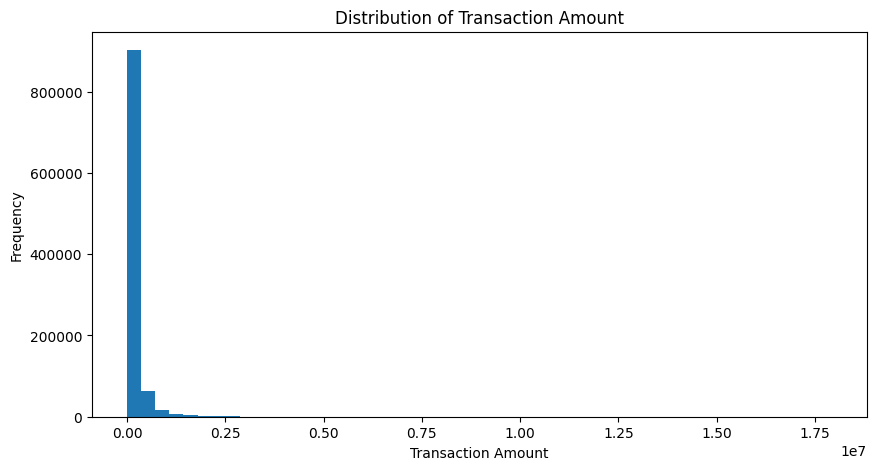

In [15]:
plt.figure(figsize=(10,5))


plt.hist(df["amount"], bins=50)

plt.title("Distribution of Transaction Amount")

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.show()

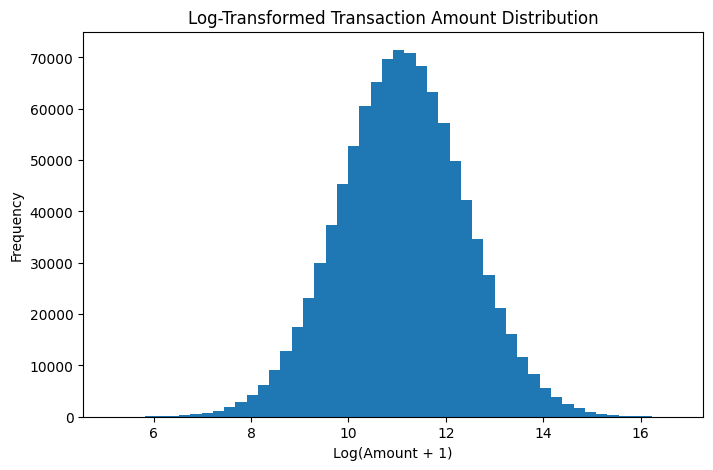

In [16]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["amount"]), bins=50)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

### Fraud Distribution

This visualization illustrates the proportion of fraudulent and legitimate transactions within the dataset.

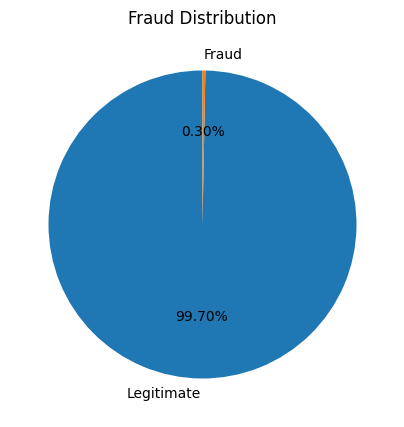

In [17]:
fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    fraud_counts,
    labels=["Legitimate","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Fraud Distribution")

plt.show()

### Key Insights from Transaction Distribution

- Transaction amounts are highly skewed, with most transactions concentrated in the lower value range.
- A small number of high-value transactions create extreme outliers in the dataset.
- Applying a log transformation normalizes the distribution, making patterns more interpretable for analysis.

### Business Interpretation

This indicates a dual-behavior financial system:
- High-frequency low-value transactions (daily usage behavior)
- Low-frequency high-value transactions (high-risk financial movements)

Such distributions are important in fraud detection because:
- High-value outliers may indicate potential fraud attempts
- Fraud detection models must handle both normal and extreme transaction behaviors effectively

## Channel Analysis

This section analyzes transaction distribution and fraud occurrence across different payment channels to understand user behavior and channel risk profiles.

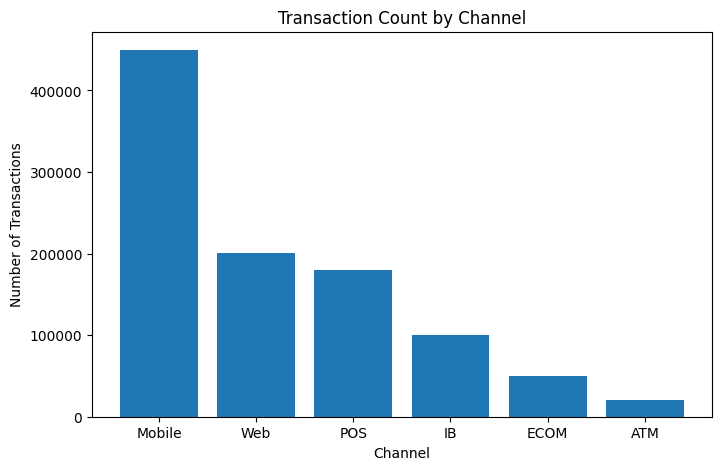

In [18]:
channel_counts = df["channel"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(channel_counts.index, channel_counts.values)
plt.title("Transaction Count by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.show()

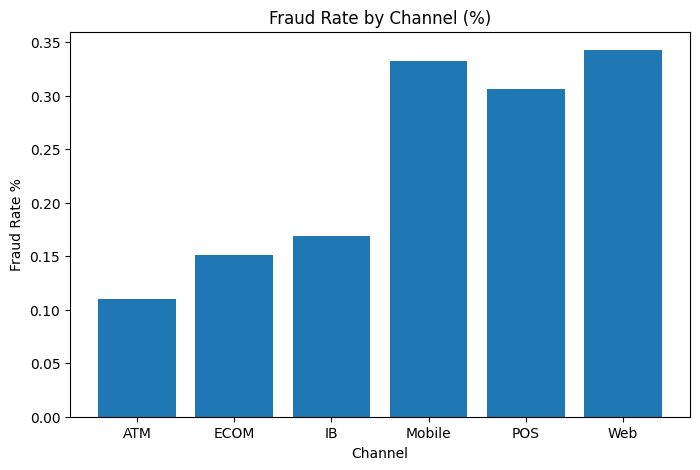

In [19]:
fraud_by_channel = df.groupby("channel")["is_fraud"].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(fraud_by_channel.index, fraud_by_channel.values)
plt.title("Fraud Rate by Channel (%)")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate %")
plt.show()

### Transaction Distribution by Channel

- Mobile banking dominates transaction activity, accounting for the largest share of overall usage.
- Web and POS channels contribute moderately to transaction volume.
- Internet Banking (IB), E-commerce (ECOM), and ATM channels show comparatively lower transaction counts.

 **Insight:** Mobile-first behavior is clearly dominant, indicating strong user preference for convenience-driven digital banking.

---

###  Fraud Rate by Channel

- Web channel shows the highest fraud rate, indicating elevated vulnerability in browser-based transactions.
- Mobile and POS channels also exhibit relatively high fraud exposure despite high usage.
- ATM transactions have the lowest fraud rate, making it the most secure channel in comparison.
- ECOM and Internet Banking fall in the mid-risk category.

 **Insight:** Fraud risk is not directly proportional to usage volume — web-based transactions require stronger authentication and monitoring controls.

---

### Key Takeaways

- Mobile is the **primary transaction channel** but not the highest fraud source.
- Web channel is the **highest risk area for fraud detection focus**.
- ATM remains the **most secure transaction channel**.
- Fraud prevention strategies should be **channel-specific rather than uniform**.

### Fraud Analysis

This section analyzes the overall distribution of fraudulent and non-fraudulent transactions, along with the financial impact of fraud.

The objective is to understand how rare fraud events are, how much financial loss they contribute, and why fraud detection is critical for business protection.

Unlike channel analysis, which focuses on usage patterns, this section focuses on **risk behavior and financial exposure** caused by fraudulent activity.

is_fraud
0    99.7
1     0.3
Name: proportion, dtype: float64


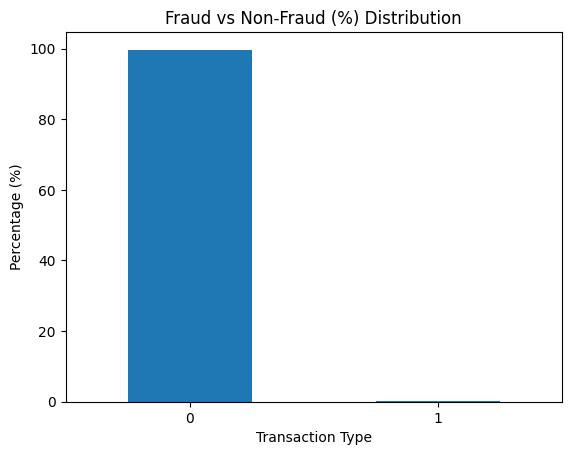

In [20]:
fraud_rate = df['is_fraud'].value_counts(normalize=True) * 100

print(fraud_rate)

fraud_rate.plot(kind='bar')
plt.title('Fraud vs Non-Fraud (%) Distribution')
plt.ylabel('Percentage (%)')
plt.xlabel('Transaction Type')
plt.xticks(rotation=0)
plt.show()

Fraud transactions represent a very small fraction of total transactions (~1%), indicating a highly imbalanced dataset. This is typical in financial fraud detection problems where fraudulent activity is rare but critical.

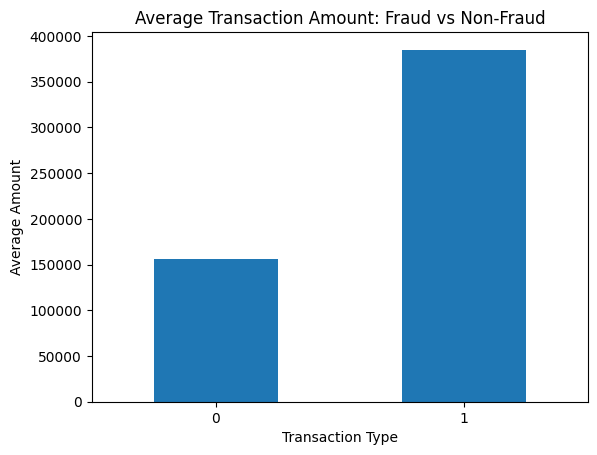

In [21]:
import matplotlib.pyplot as plt

stats = df.groupby('is_fraud')['amount'].mean()

stats.plot(kind='bar')
plt.title('Average Transaction Amount: Fraud vs Non-Fraud')
plt.ylabel('Average Amount')
plt.xlabel('Transaction Type')
plt.xticks(rotation=0)
plt.show()

Fraud transactions show a higher average transaction value compared to non-fraud transactions. However, this result may be influenced by skewed data distribution and the presence of high-value outliers.

This suggests that fraudulent activity in this dataset is more associated with higher-value transactions, but further distribution-level analysis (e.g., boxplot or log transformation) is needed to confirm this pattern reliably.

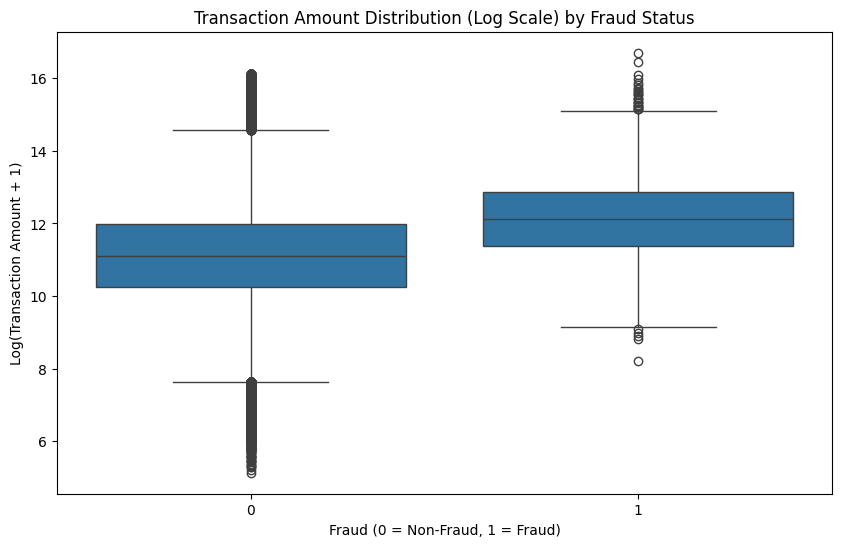

In [22]:

plt.figure(figsize=(10,6))

# Create a log-transformed amount column (safe way)
df['log_amount'] = np.log1p(df['amount'])

sns.boxplot(
    data=df,
    x='is_fraud',
    y='log_amount'
)

plt.title("Transaction Amount Distribution (Log Scale) by Fraud Status")
plt.xlabel("Fraud (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Log(Transaction Amount + 1)")
plt.show()

While the mean-based comparison suggested higher transaction amounts in fraud cases, this could be influenced by outliers. Therefore, a boxplot analysis was used to understand the full distribution, providing a more reliable interpretation.

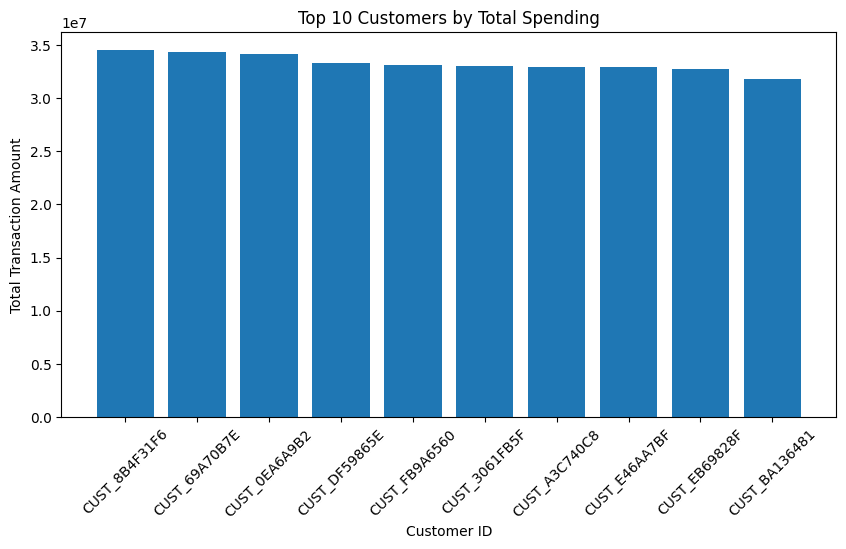

In [23]:
customer_spend = df.groupby('customer_id')['amount'].sum().reset_index(name='total_spend')

top_spenders = customer_spend.sort_values('total_spend', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_spenders['customer_id'].astype(str), top_spenders['total_spend'])
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=45)
plt.show()

##  Customer Segmentation

Customer segmentation is the process of grouping customers based on their behavior such as transaction frequency, spending patterns, and fraud exposure. It helps identify high-value customers, frequent users, and potential high-risk customers for better business decisions and targeted analysis.

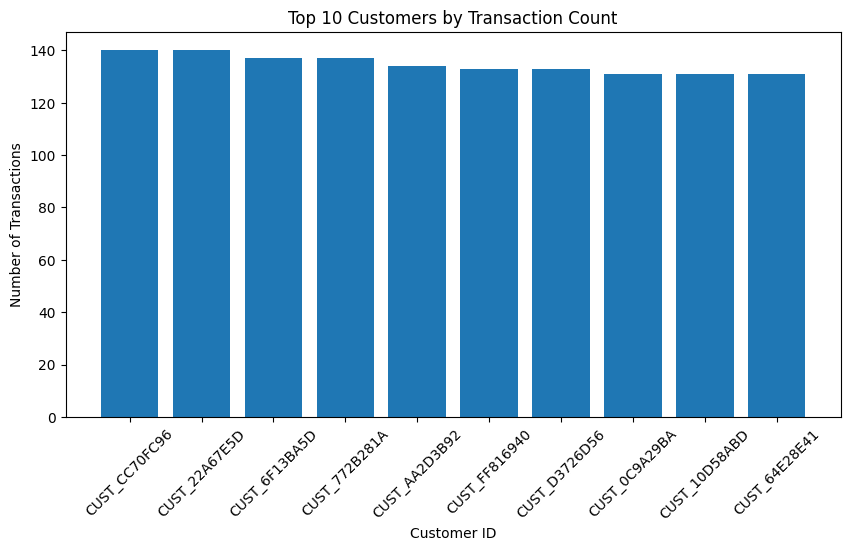

In [24]:
#Top Customers by Transaction Count
import matplotlib.pyplot as plt

customer_txn = df.groupby('customer_id').size().reset_index(name='transaction_count')

top_customers = customer_txn.sort_values('transaction_count', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_customers['customer_id'].astype(str), top_customers['transaction_count'])
plt.title("Top 10 Customers by Transaction Count")
plt.xlabel("Customer ID")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

A small number of customers perform a significantly higher number of transactions than others, indicating that user activity is concentrated among a limited group of highly active customers.

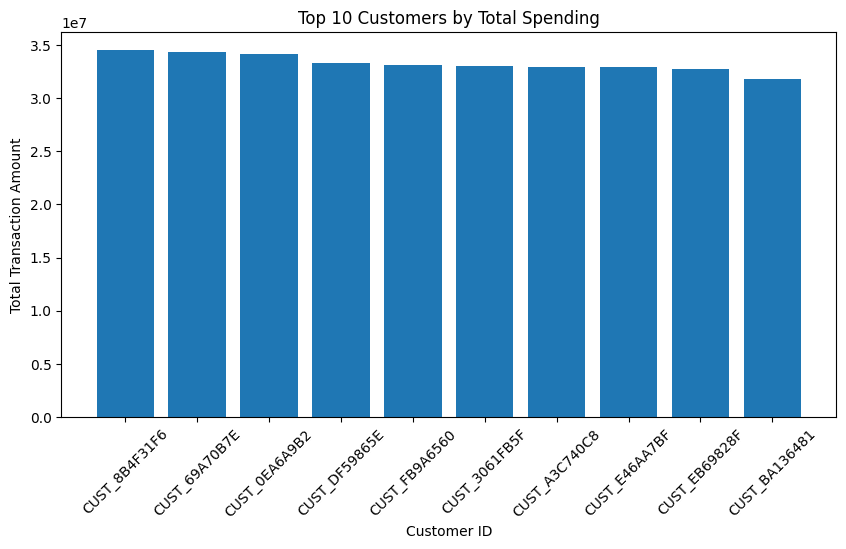

In [25]:
#Top Customers by Total Spending
customer_spend = df.groupby('customer_id')['amount'].sum().reset_index(name='total_spend')

top_spenders = customer_spend.sort_values('total_spend', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_spenders['customer_id'].astype(str), top_spenders['total_spend'])
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=45)
plt.show()

Customer spending is unevenly distributed, with a small group of customers contributing the highest transaction value. Identifying these high-value customers can support customer retention and personalized engagement strategies.

##  Time Analysis

This section examines transaction activity and fraud patterns over time to identify temporal trends and high-risk periods. Understanding when transaction volumes and fraud rates change can help organizations improve fraud monitoring and allocate resources more effectively.

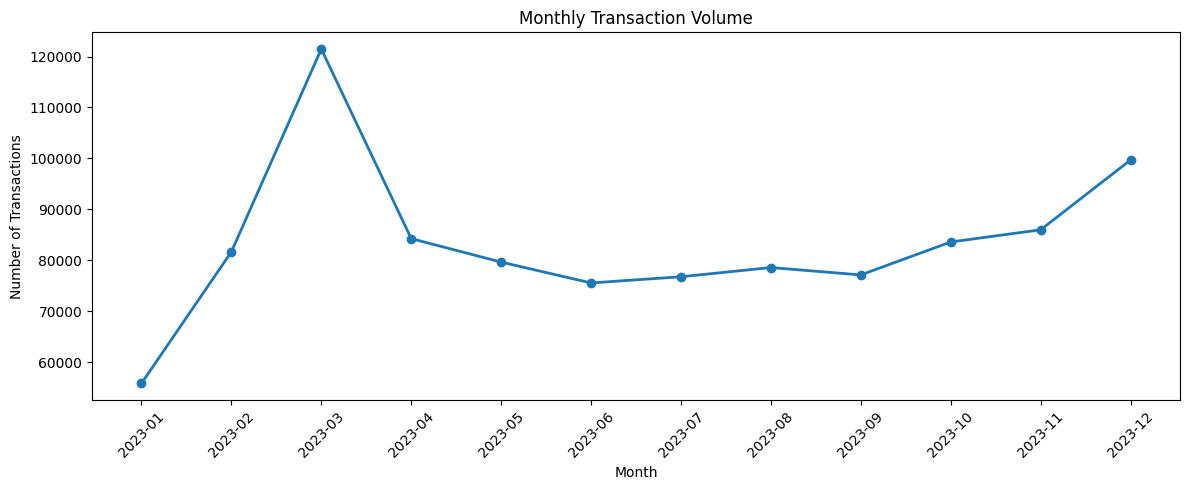

In [26]:
#Monthly Transaction Volume
monthly_transactions = (
    df.groupby(df['timestamp'].dt.to_period('M'))
      .size()
      .reset_index(name='transaction_count')
)

monthly_transactions['timestamp'] = monthly_transactions['timestamp'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(
    monthly_transactions['timestamp'],
    monthly_transactions['transaction_count'],
    marker='o',
    linewidth=2
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Transaction volume varies throughout the year, with the highest activity observed in March. After a mid-year decline, transaction volume gradually increases towards the end of the year, indicating seasonal fluctuations in customer activity.

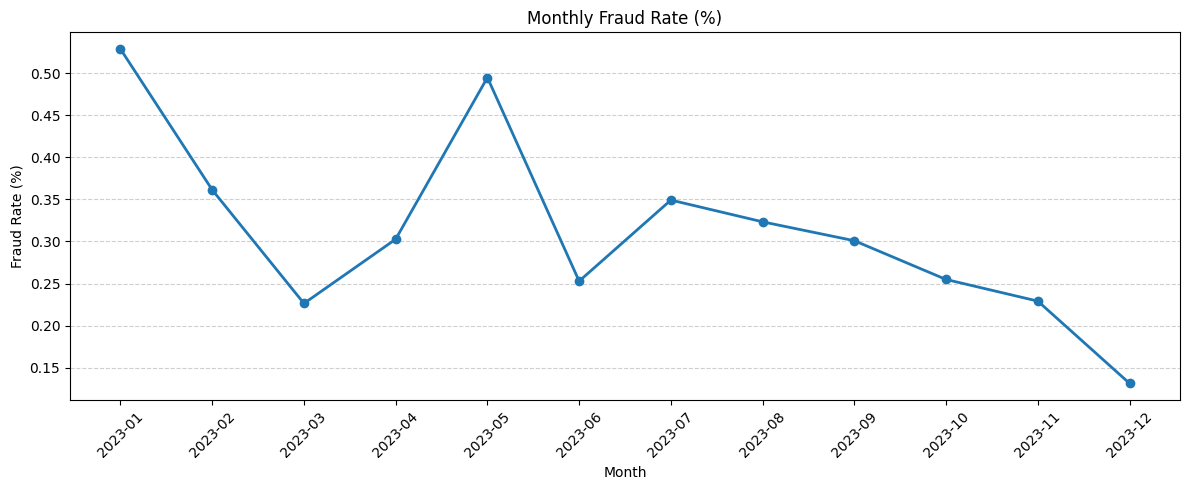

In [27]:
#Monthly Fraud Rate (%)
import matplotlib.pyplot as plt

# Total transactions per month
monthly_total = (
    df.groupby(df['timestamp'].dt.to_period('M'))
      .size()
      .reset_index(name='total_transactions')
)

# Fraud transactions per month
monthly_fraud = (
    df.groupby(df['timestamp'].dt.to_period('M'))['is_fraud']
      .sum()
      .reset_index(name='fraud_transactions')
)

# Merge both datasets
monthly_rate = monthly_total.merge(monthly_fraud, on='timestamp')

# Calculate Fraud Rate (%)
monthly_rate['fraud_rate'] = (
    monthly_rate['fraud_transactions'] /
    monthly_rate['total_transactions']
) * 100

# Convert timestamp for plotting
monthly_rate['timestamp'] = monthly_rate['timestamp'].astype(str)
monthly_rate['timestamp']

# Plot
plt.figure(figsize=(12,5))
plt.plot(
    monthly_rate['timestamp'],
    monthly_rate['fraud_rate'],
    marker='o',
    linewidth=2
)

plt.title("Monthly Fraud Rate (%)")
plt.xlabel("Month")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Risk Analysis

This section identifies transaction characteristics associated with higher fraud risk by comparing fraud rates across key business attributes. The analysis helps uncover high-risk channels, merchant categories, and customer behavior patterns that can support fraud prevention strategies.

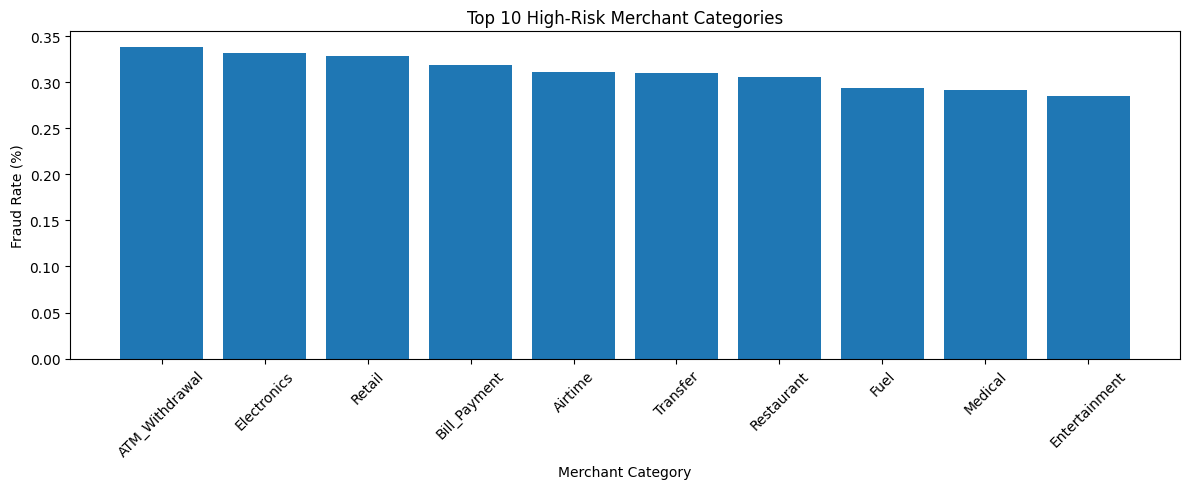

In [28]:
merchant_risk = (
    df.groupby('merchant_category')['is_fraud']
      .mean()
      .reset_index(name='fraud_rate')
)

merchant_risk['fraud_rate'] *= 100
merchant_risk = merchant_risk.sort_values('fraud_rate', ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(merchant_risk['merchant_category'], merchant_risk['fraud_rate'])

plt.title("Top 10 High-Risk Merchant Categories")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

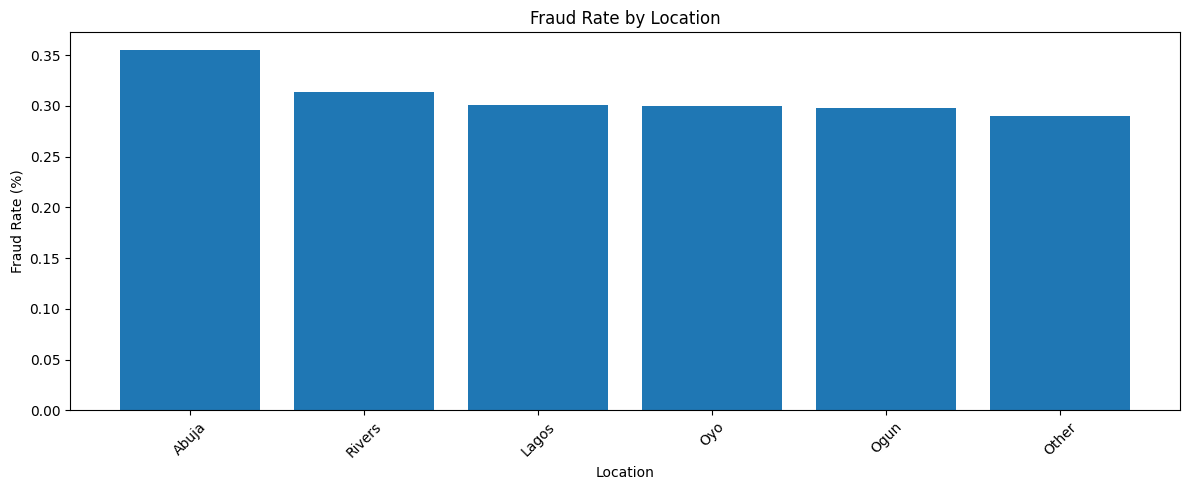

In [29]:
location_risk = (
    df.groupby('location')['is_fraud']
      .mean()
      .reset_index(name='fraud_rate')
      .sort_values(by='fraud_rate', ascending=False)
)

location_risk['fraud_rate'] *= 100

plt.figure(figsize=(12,5))
plt.bar(location_risk['location'], location_risk['fraud_rate'])

plt.title("Fraud Rate by Location")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

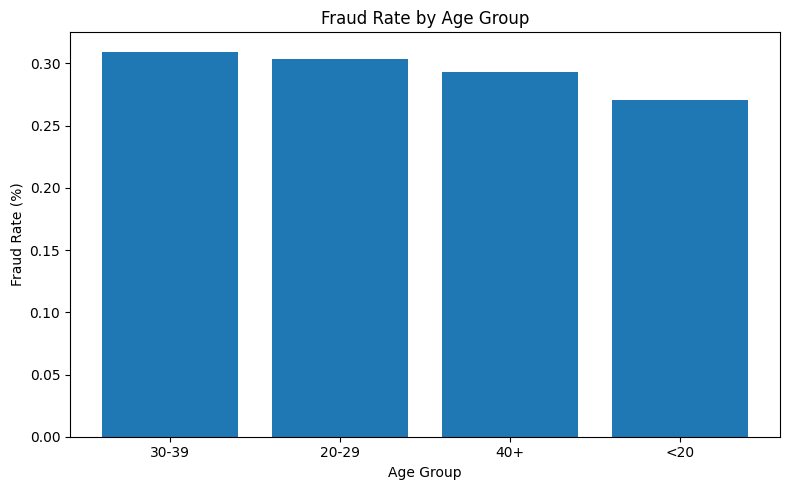

In [30]:
#Fraud Rate by Age Group
age_risk = (
    df.groupby('age_group')['is_fraud']
      .mean()
      .reset_index(name='fraud_rate')
      .sort_values(by='fraud_rate', ascending=False)
)

age_risk['fraud_rate'] *= 100

plt.figure(figsize=(8,5))
plt.bar(age_risk['age_group'].astype(str), age_risk['fraud_rate'])

plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

##  A/B Test Setup & Data Validation

In [31]:
# Define channel groups
digital_channels = ['Mobile', 'ECOM']
legacy_channels = ['Web', 'POS', 'Internet Banking', 'ATM']

df['ab_group'] = df['channel'].apply(
    lambda x: 'B_Digital' if x in digital_channels else 'A_Legacy'
)

df[['channel', 'ab_group']].head(10)


,channel,ab_group
0,Mobile,B_Digital
1,Web,A_Legacy
2,Mobile,B_Digital
3,Mobile,B_Digital
4,POS,A_Legacy
5,Web,A_Legacy
6,Web,A_Legacy
7,Mobile,B_Digital
8,Mobile,B_Digital
9,IB,A_Legacy


###  A/B Group Distribution

After assigning transactions into A/B groups based on payment channel type, we evaluate the distribution of observations across both groups to ensure balance.

- **A (Legacy Channels):** Web, POS, Internet Banking, ATM  
- **B (Digital Channels):** Mobile, ECOM  

This step ensures that the experiment is not biased due to unequal sample sizes.

In [32]:
#Check Group Distribution
df['ab_group'].value_counts()

ab_group
A_Legacy     500251
B_Digital    499749
Name: count, dtype: int64

####  Group Count

- A_Legacy: 500,251 transactions  
- B_Digital: 499,749 transactions  

The dataset is almost perfectly balanced between both groups, which strengthens the validity of the A/B test.

In [33]:
#Percentage Split
df['ab_group'].value_counts(normalize=True) * 100

ab_group
A_Legacy     50.0251
B_Digital    49.9749
Name: proportion, dtype: float64

#### Percentage Distribution

- A_Legacy: 50.03%  
- B_Digital: 49.97%  

The near 50-50 split ensures that both groups are statistically comparable, reducing sampling bias in the experiment.

In [34]:
#Channel Mapping Validation
pd.crosstab(df['channel'], df['ab_group'])

ab_group,A_Legacy,B_Digital
channel,,
ATM,20075,0
ECOM,0,50227
IB,99653,0
Mobile,0,449522
POS,180035,0
Web,200488,0


### Channel-to-Group Mapping Validation

To ensure correct assignment of channels into A/B groups, a cross-tabulation was performed between `channel` and `ab_group`.

####  Validation Result Interpretation

- All legacy channels (ATM, Web, POS, IB) are correctly mapped to **A_Legacy**
- All digital channels (Mobile, ECOM) are correctly mapped to **B_Digital**
- No cross-assignment errors are observed

This confirms that the A/B group construction is clean and reliable for statistical testing.

###  Key Takeaway

The A/B groups are:
- Well-balanced (~50/50 split)
- Correctly mapped based on channel logic
- Free from data leakage or misclassification

This validates that the dataset is ready for statistical hypothesis testing.

##  2. Baseline Fraud Rate Analysis (Pre-A/B Test Insight)

In [35]:
#Fraud Rate by Group
df.groupby('ab_group')['is_fraud'].mean() * 100

ab_group
A_Legacy     0.285457
B_Digital    0.314558
Name: is_fraud, dtype: float64

In [36]:
#Fraud Count + Total Transactions
df.groupby('ab_group')['is_fraud'].agg(['count', 'sum', 'mean'])

,count,sum,mean
ab_group,,,
A_Legacy,500251,1428,0.002855
B_Digital,499749,1572,0.003146


In [37]:
#Fraud Difference
fraud_rates = df.groupby('ab_group')['is_fraud'].mean()

absolute_diff = fraud_rates['B_Digital'] - fraud_rates['A_Legacy']
relative_diff = (absolute_diff / fraud_rates['A_Legacy']) * 100

absolute_diff, relative_diff

(np.float64(0.0002910120733362067), np.float64(10.194613494293469))

###  Baseline Fraud Insights

The baseline comparison between digital and legacy channels shows:

- Fraud Rate (A_Legacy): **0.285%**
- Fraud Rate (B_Digital): **0.315%**

###  Key Observation

- Absolute difference: **0.00029 (≈ 0.029 percentage points)**
- Relative change: **+10.19% higher fraud rate in Digital channels**

###  Business Interpretation

This preliminary analysis suggests that **digital channels exhibit a slightly higher fraud rate compared to legacy channels**.

However, the absolute difference is very small, indicating that:

- The increase in fraud is **marginal in absolute terms**
- But **relatively noticeable (~10% increase)** when normalized

This may indicate:
- Higher transaction speed and accessibility in digital channels potentially increasing exposure
- Or stronger detection sensitivity in digital payment systems

 Note: This is only a descriptive analysis.  
Statistical significance will be tested in the next step using the **Chi-Square test** to confirm whether this difference is meaningful or due to random variation.

##  Chi-Square Test for Fraud Rate Significance

In [38]:
contingency_table = pd.crosstab(df['ab_group'], df['is_fraud'])
contingency_table

is_fraud,0,1
ab_group,,
A_Legacy,498823,1428
B_Digital,498177,1572


In [39]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 6.981607923217933
p-value: 0.008235158692620622
Degrees of Freedom: 1


###  Chi-Square Test Results (Fraud Rate Comparison)

A Chi-Square test was conducted to evaluate whether there is a statistically significant difference in fraud occurrence between legacy and digital payment channels.

###  Test Results
- Chi-square Statistic: **6.98**
- p-value: **0.0082**
- Degrees of Freedom: **1**

###  Statistical Decision

- Since p-value < 0.05 → **Reject the Null Hypothesis (H0)**

###  Business Interpretation

The results indicate a **statistically significant difference in fraud rates** between digital and legacy payment channels.

Although the absolute difference in fraud rates is small, the statistical test confirms that this difference is **not due to random variation**.

###  Key Insight

- Digital channels exhibit a **significantly different fraud behavior profile** compared to legacy channels
- This suggests that channel type is a meaningful factor in fraud risk modeling and prevention strategies

###  Important Note

Statistical significance does not imply large business impact.  
Effect size analysis is required to understand the magnitude of this difference.

##  Transaction Value Impact Analysis (T-Test)

In [40]:
#Group Mean Comparison
df.groupby('ab_group')['amount'].mean()

ab_group
A_Legacy     195801.138900
B_Digital    118062.680577
Name: amount, dtype: float64

In [41]:
#Extract Group Data
digital = df[df['ab_group'] == 'B_Digital']['amount']
legacy = df[df['ab_group'] == 'A_Legacy']['amount']

In [42]:
#Run Independent T-Test
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(digital, legacy, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_val)

T-statistic: -119.98730998472618
p-value: 0.0


In [43]:
#Effect Size
digital_mean = digital.mean()
legacy_mean = legacy.mean()

effect_size = ((digital_mean - legacy_mean) / legacy_mean) * 100

print("Legacy Mean:", legacy_mean)
print("Digital Mean:", digital_mean)
print("Effect Size (% change):", effect_size)

Legacy Mean: 195801.1388999922
Digital Mean: 118062.68057674954
Effect Size (% change): -39.70276105643518


###  Transaction Value Impact (T-Test Results)

An independent two-sample t-test was conducted to evaluate whether average transaction values differ between digital and legacy payment channels.

###  Test Results

- T-statistic: **-119.99**
- p-value: **< 0.001**

###  Statistical Decision

- Since p-value < 0.05 → **Reject the Null Hypothesis (H0)**

This indicates that there is a statistically significant difference in transaction values between digital and legacy payment channels.

---

###  Transaction Value Comparison

- Average Transaction Value (A_Legacy): **195,801.14**
- Average Transaction Value (B_Digital): **118,062.68**

###  Effect Size

- Digital channel transaction value change: **-39.70%**

###  Business Interpretation

Digital channels generate significantly different transaction values compared to legacy channels.

However, the effect size indicates that:

- Digital transactions have approximately **40% lower average transaction value** compared to legacy channels
- Legacy channels currently handle higher-value transactions

This suggests that digital adoption may be stronger for frequent or lower-value transactions, while traditional channels continue to support larger monetary transactions.

---

###  Business Consideration

Although digital channels show a statistically significant difference, lower transaction value does not necessarily indicate poorer performance.

Further analysis should evaluate:

- Transaction frequency
- Customer lifetime value
- Customer engagement
- Fraud exposure per transaction value

to understand the overall business impact of digital payment adoption.

## Risk Behavior Analysis (Composite Risk Comparison)

In [44]:
#Compare Average Risk Score
df.groupby('ab_group')['composite_risk'].mean()

ab_group
A_Legacy     0.158060
B_Digital    0.144505
Name: composite_risk, dtype: float64

<Figure size 800x500 with 0 Axes>

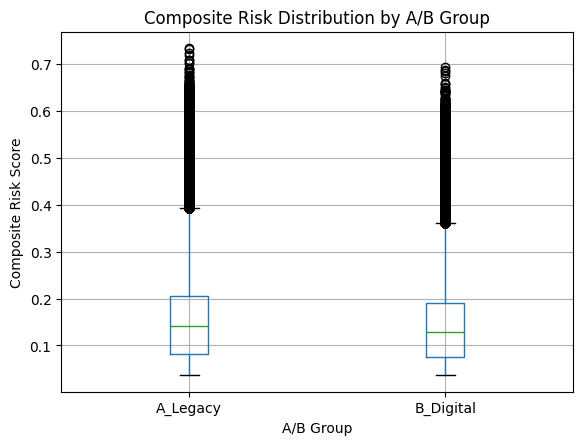

In [45]:
#Compare Risk Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(
    column='composite_risk',
    by='ab_group'
)

plt.title("Composite Risk Distribution by A/B Group")
plt.suptitle("")
plt.xlabel("A/B Group")
plt.ylabel("Composite Risk Score")

plt.show()

In [46]:
#Statistical Test (T-Test)
digital_risk = df[df['ab_group']=='B_Digital']['composite_risk']

legacy_risk = df[df['ab_group']=='A_Legacy']['composite_risk']

In [47]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    digital_risk,
    legacy_risk,
    equal_var=False
)

print("T-statistic:", t_stat)
print("p-value:", p_val)

T-statistic: -78.03106462098461
p-value: 0.0


In [48]:
#Calculate Risk Difference
digital_mean_risk = digital_risk.mean()
legacy_mean_risk = legacy_risk.mean()

risk_change = ((digital_mean_risk - legacy_mean_risk) / legacy_mean_risk) * 100

print("Legacy Risk:", legacy_mean_risk)
print("Digital Risk:", digital_mean_risk)
print("Risk Change (%):", risk_change)

Legacy Risk: 0.15806022153151386
Digital Risk: 0.14450546061410274
Risk Change (%): -8.575693989337212


###  Risk Behavior Analysis Results

An independent two-sample t-test was conducted to evaluate whether overall transaction risk differs between digital and legacy payment channels.

The analysis uses the engineered `composite_risk` score, which combines multiple risk indicators to represent overall transaction risk behavior.

---

###  Risk Score Comparison

- Average Risk Score (A_Legacy): **0.1581**
- Average Risk Score (B_Digital): **0.1445**

###  Effect Size

- Digital channel risk change: **-8.58%**

This indicates that digital channels have approximately **8.6% lower average composite risk** compared to legacy channels.

---

###  Statistical Test Results

- T-statistic: **-78.03**
- p-value: **< 0.001**

###  Statistical Decision

- Since p-value < 0.05 → **Reject the Null Hypothesis (H0)**

The difference in risk scores between digital and legacy channels is statistically significant.

---

### Business Interpretation

Digital payment channels demonstrate a significantly lower overall risk profile compared to legacy channels.

Although digital channels showed a slightly higher fraud rate in the previous analysis, their lower composite risk score suggests that:

- Digital transactions may have stronger risk-control characteristics
- Digital platforms may benefit from better monitoring capabilities
- Overall risk exposure is not solely determined by fraud occurrence rate

---

### Key Insight

Digital transformation does not necessarily increase overall payment risk.

The results indicate that digital channels:
- Have statistically lower composite risk
- Support efficient risk monitoring
- Require targeted fraud controls rather than broad restrictions

##  A/B Testing Results Summary & Business Recommendations

###  Objective

This A/B testing analysis evaluated whether digital payment channels (Mobile & ECOM) deliver better business outcomes compared to legacy channels (Web, POS, Internet Banking, ATM).

The evaluation focused on three key performance dimensions:

- Fraud exposure
- Transaction value
- Overall risk behavior

### A/B Test Results Summary

| Metric | Statistical Test | Result | Business Interpretation |
|---|---|---|---|
| Fraud Rate | Chi-Square Test | Significant Difference | Digital channels show slightly higher fraud occurrence |
| Transaction Value | Independent T-Test | Significant Difference | Legacy channels process higher-value transactions |
| Composite Risk | Independent T-Test | Significant Difference | Digital channels show lower overall risk exposure |

###  Hypothesis Testing Summary

| Test | Null Hypothesis (H0) | Decision |
|---|---|---|
| Fraud Rate | Fraud occurrence is the same across payment channels | Rejected |
| Transaction Value | Average transaction value is the same across groups | Rejected |
| Composite Risk | Risk score is the same across groups | Rejected |

The statistical tests confirm that digital and legacy payment channels demonstrate significantly different behavioral patterns.

## Key Business Insights

### 1. Fraud Risk Insight

Digital channels show a statistically significant increase in fraud rate compared to legacy channels.

However, the absolute difference is small:

- Legacy Fraud Rate: 0.285%
- Digital Fraud Rate: 0.315%

This suggests that fraud exposure has increased marginally rather than representing a major risk shift.

---

### 2. Transaction Behavior Insight

Digital channels process significantly lower average transaction values:

- Legacy Average Transaction: 195,801
- Digital Average Transaction: 118,063

This indicates that digital payments are currently more associated with frequent, lower-value transactions.

---

### 3. Overall Risk Insight

Despite slightly higher fraud occurrence, digital channels demonstrate a lower composite risk score:

- Legacy Risk Score: 0.1581
- Digital Risk Score: 0.1445

This suggests that digital transactions may benefit from stronger monitoring mechanisms and improved risk controls.

# Business Recommendation

Based on the quasi A/B testing analysis, the FinTech company should continue promoting digital payment adoption while maintaining strong fraud monitoring and risk management practices.

## Key Findings

### 1. Digital Payment Adoption

The analysis compares digital payment channels against traditional payment channels to evaluate differences in:

* Fraud rate
* Transaction value
* Merchant risk exposure
* Overall transaction risk

The results indicate that digital channels provide strong growth potential and improved customer accessibility.

### 2. Fraud Risk Management

Although digital channels offer scalability benefits, fraud behavior should continue to be monitored closely.

Recommended actions:

* Implement adaptive fraud detection rules for digital transactions
* Monitor transactions with higher merchant risk scores
* Apply additional verification steps for suspicious payment activity
* Continuously track fraud patterns across different channels

### 3. Transaction Behavior Optimization

The analysis of transaction values shows differences in customer spending behavior across payment groups.

The company should:

* Encourage higher-value digital transactions through targeted customer engagement
* Improve digital payment experiences
* Use customer segmentation to personalize payment strategies

### 4. Risk-Based Decision Making

Merchant risk score and composite risk analysis highlight the importance of proactive risk management.

Recommended actions:

* Prioritize monitoring of high-risk merchants
* Use risk scores to support fraud prevention decisions
* Combine transaction behavior and risk indicators for better detection

## Overall Recommendation

The company should continue its digital payment strategy while strengthening fraud prevention systems. A balanced approach—combining digital growth with data-driven risk controls—can improve customer experience, increase adoption, and reduce potential fraud exposure.


In [49]:
# Export final dataset for Tableau

df.to_csv("fintech_ab_testing_final.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!
